In [69]:
using DriftDiffusionModels
using CSV
using DataFrames
using Distributions
using Plots
using StatsPlots
using StatsBase
using Statistics

In [11]:
results_dir = "../results/"

# file paths
elbo_csv = "eddm_elbo_history_by_rat.csv"
trial_post_csv = "eddm_trial_posteriors_by_rat.csv.gz"
hyper_csv = "eddm_hyperparams_by_rat.csv"

# load data into DataFrames
elbo_df = CSV.read(results_dir * elbo_csv, DataFrame)
trial_post_df = CSV.read(results_dir * trial_post_csv, DataFrame)
hyper_df = CSV.read(results_dir * hyper_csv, DataFrame)

Row,rat_name,m_uB,m_uτ,m_uv,m_ua0,logσ0_uB,logσ0_uτ,logσ0_uv,logσ0_ua0,B_group_mean,τ_group_mean,v_group_mean,a0_group_mean
,String7,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,Denna,0.508414,-0.372245,-0.876991,0.115254,-1.46626,-2.36661,-0.499769,-1.25393,1.66265,0.689185,0.416033,0.528782
2,Dopey,0.44076,-0.325968,-0.787446,-0.15591,-1.67914,-2.13725,-0.490043,-1.27341,1.55389,0.721828,0.455005,0.461101
3,Draco,0.368197,-0.549781,-0.643003,-0.4083,-1.54813,-2.38398,-0.587655,-1.32556,1.44513,0.577076,0.525711,0.39932
4,Randy,0.500179,-0.453652,-0.318211,-0.470805,-1.74996,-2.28396,-0.621957,-1.35668,1.64902,0.635304,0.72745,0.384426
5,Remy,0.325738,-0.661258,-0.470534,-0.361433,-1.69892,-1.97331,-0.693089,-1.30789,1.38505,0.516202,0.624669,0.410613
6,Rhea,0.481352,-0.453875,-0.51659,-0.277232,-1.60898,-1.95765,-0.673148,-1.29469,1.61826,0.635162,0.596551,0.431132
7,Robert,0.530627,-0.732575,-0.639243,0.399873,-1.71229,-1.82715,-0.552589,-1.28667,1.7,0.48067,0.527691,0.598657
8,Ron,0.389696,-0.673733,-0.575903,-0.311881,-1.65679,-2.02577,-0.523066,-1.29657,1.47653,0.509802,0.562197,0.422656
9,Rudy,0.438755,-0.577443,-0.973976,-0.0904594,-1.7519,-1.80727,-0.494441,-1.23928,1.55078,0.561332,0.377579,0.477401


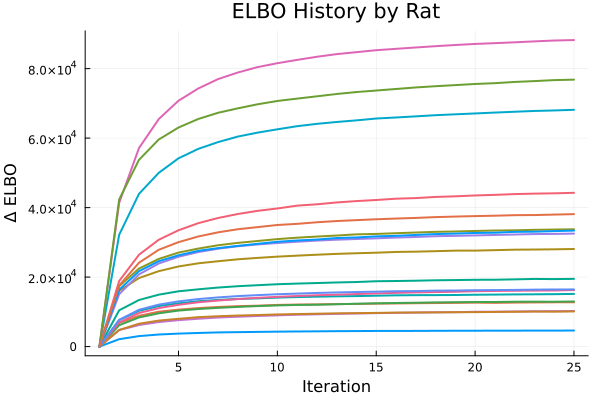

In [20]:
# plot the ELBOs so we can confirm models converged
grouped_elbo = groupby(elbo_df, :rat_name)
plt = plot(title="ELBO History by Rat", xlabel="Iteration", ylabel="Δ ELBO")
for g in grouped_elbo
    rat_name = unique(g.rat_name)[1]
    plot!(plt, g.iter, g.elbo .- minimum(g.elbo), label=rat_name, lw=2, legend=false)
end
display(plt)

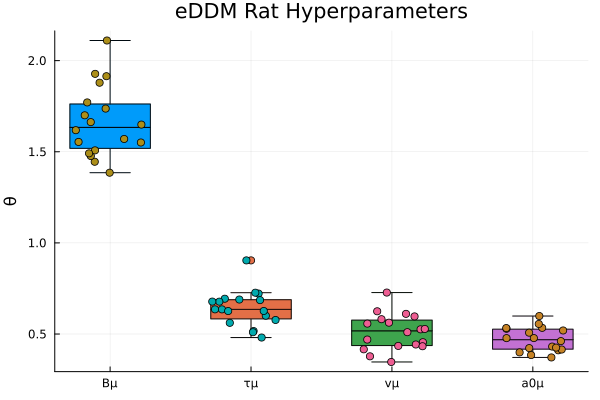

In [34]:
# make a plot of the hyperparameters across rats
plot(legend=false)
@df hyper_df boxplot!(["Bμ" for i in 1:nrow(hyper_df)], :B_group_mean)
@df hyper_df boxplot!(["τμ" for i in 1:nrow(hyper_df)], :τ_group_mean)
@df hyper_df boxplot!(["vμ" for i in 1:nrow(hyper_df)], :v_group_mean)
@df hyper_df boxplot!(["a0μ" for i in 1:nrow(hyper_df)], :a0_group_mean)

@df hyper_df dotplot!(["Bμ" for i in 1:nrow(hyper_df)], :B_group_mean)
@df hyper_df dotplot!(["τμ" for i in 1:nrow(hyper_df)], :τ_group_mean)
@df hyper_df dotplot!(["vμ" for i in 1:nrow(hyper_df)], :v_group_mean)
@df hyper_df dotplot!(["a0μ" for i in 1:nrow(hyper_df)], :a0_group_mean)

ylabel!("θ")
title!("eDDM Rat Hyperparameters")

In [93]:
# get autocorrlation of each of the trial parameters per rat
rats = unique(trial_post_df.rat_name)

function rat_pacf(rat_name::String7, max_lag::Int = 20)
    sub_df = filter(row -> row.rat_name == rat_name, trial_post_df)
    pacf_dict = DataFrame(
        Dict(
        "B_pacf" => pacf(sub_df.B_mean, 1:max_lag),
        "τ_pacf" => pacf(sub_df.τ_mean, 1:max_lag),
        "v_pacf" => pacf(sub_df.v_mean, 1:max_lag),
        "a0_pacf" => pacf(sub_df.a0_mean, 1:max_lag),
    )
    )

    return pacf_dict
end

pacfs = Vector{DataFrame}(undef, length(rats))

for (i, rat) in enumerate(rats)
    pacfs[i] = rat_pacf(rat)
end

# one df 
combined = vcat(
    (hcat(df, DataFrame(rat = fill(rat, nrow(df))))
     for (df, rat) in zip(pacfs, rats))...;
    cols = :union,
)

combined.lag = repeat(1:20, length(rats))

mean_pacf = combine(groupby(combined, :lag),
    :B_pacf => mean,
    :a0_pacf => mean,
    :v_pacf => mean,
    :τ_pacf => mean
)

sem_pacf = combine(groupby(combined, :lag),
    :B_pacf => (x -> std(x) / sqrt(length(x))) => :B_pacf_sem,
    :a0_pacf => (x -> std(x) / sqrt(length(x))) => :a0_pacf_sem,
    :v_pacf => (x -> std(x) / sqrt(length(x))) => :v_pacf_sem,
    :τ_pacf => (x -> std(x) / sqrt(length(x))) => :τ_pacf_sem
)



Row,lag,B_pacf_sem,a0_pacf_sem,v_pacf_sem,τ_pacf_sem
,Int64,Float64,Float64,Float64,Float64
1,1,0.0168577,0.0208875,0.0030983,0.0203154
2,2,0.0102897,0.00947991,0.0024998,0.0138681
3,3,0.00737425,0.00703601,0.00311128,0.00952269
4,4,0.00570828,0.00658021,0.00298536,0.00801247
5,5,0.00458899,0.00397028,0.00242474,0.00712503
6,6,0.00379536,0.00358093,0.0023257,0.00537762
7,7,0.00368383,0.00427106,0.00196645,0.00569592
8,8,0.00297585,0.00286707,0.00241603,0.00497956
9,9,0.00361432,0.00348502,0.00236151,0.00427596


In [95]:
p = plot(title="Mean PACF of Trial Parameters Across Rats", xlabel="Lag", ylabel="PACF", fontfamily="helvetica")

plot!(p, mean_pacf.lag, mean_pacf.B_pacf_mean,
    ribbon=1.96 * sem_pacf.B_pacf_sem,
    label="B",
    lw=2,
)

plot!(p, mean_pacf.lag, mean_pacf.τ_pacf_mean,
    ribbon=1.96 *sem_pacf.τ_pacf_sem,
    label="τ",
    lw=2,
)

plot!(p, mean_pacf.lag, mean_pacf.v_pacf_mean,
    ribbon=1.96 *sem_pacf.v_pacf_sem,
    label="v",
    lw=2,
)

plot!(p, mean_pacf.lag, mean_pacf.a0_pacf_mean,
    ribbon=1.96 * sem_pacf.a0_pacf_sem,
    label="a0",
    lw=2,
)

savefig(p, results_dir * "eddm_trial_param_pacf.svg")

"c:\\Users\\ryansenne\\Documents\\GitHub\\24_Hour_Behavior\\results\\eddm_trial_param_pacf.svg"

In [96]:
function pacf_rts(rat::String7, maxlags=20)
    sub_df = filter(row -> row.rat_name == rat, trial_post_df)
    rts = sub_df.rt
    pacf_vals = pacf(rts, 1:maxlags)
    pacf_df = DataFrame(RT_pacf = pacf_vals)
    return pacf_df
end

pacf_vals = Vector{DataFrame}(undef, length(rats))

for (i, rat) in enumerate(rats)
    pacf_vals[i] = pacf_rts(rat, 20)
end     

# one df 
combined_rt = vcat(
    (hcat(df, DataFrame(rat = fill(rat, nrow(df))))
     for (df, rat) in zip(pacf_vals, rats))...;
    cols = :union,
)

combined_rt.lag = repeat(1:20, length(rats))

mean_pacf = combine(groupby(combined_rt, :lag),
    :RT_pacf => mean,
)

sem_pacf = combine(groupby(combined_rt, :lag),
    :RT_pacf => (x -> std(x) / sqrt(length(x))) => :RT_pacf_sem
)



Row,lag,RT_pacf_sem
,Int64,Float64
1,1,0.0121142
2,2,0.00774809
3,3,0.00611639
4,4,0.00567267
5,5,0.00417797
6,6,0.00345846
7,7,0.00361825
8,8,0.0027211
9,9,0.00365956


In [98]:
rt_pacf = plot(title="Mean PACF of RTs Across Rats", xlabel="Lag", ylabel="PACF", fontfamily="helvetica")

plot!(rt_pacf, mean_pacf.lag, mean_pacf.RT_pacf_mean,
    ribbon=1.96 * sem_pacf.RT_pacf_sem,
    label="RT",
    lw=2,
)

savefig(rt_pacf, results_dir * "rt_pacf.svg")

"c:\\Users\\ryansenne\\Documents\\GitHub\\24_Hour_Behavior\\results\\rt_pacf.svg"